# <div style="background-color:rgba(255, 255, 255, 0.1); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(255, 255, 255, 1);"> Malus's Law</span></span></div>

In [3]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Import PHYS231.py and then run the installer function.
import PHYS231
PHYS231.Installer()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys

In [5]:
from IPython.display import HTML, display


def variable_template_builder():
    html_code = """
    <div style="background-color: #1e1e1e; padding: 15px; border-radius: 8px; font-family: sans-serif; max-width: 520px; color: #ffffff; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        <div style="margin-bottom: 10px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Variable Name(s) (comma-separated):</label>
            <input type="text" id="var_names_input" placeholder="e.g. theta_m, I, B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>
        <div style="margin-bottom: 14px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Units / Comment (Optional, comma-separated):</label>
            <input type="text" id="units_comment_input" placeholder="e.g. deg, A, T" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>
        <button id="copy_btn" onclick="copyAndReset()" style="width: 100%; padding: 10px; background-color: #2da44e; color: white; border: none; border-radius: 6px; font-weight: bold; cursor: pointer; transition: background-color 0.2s;">
            Copy Template & Reset
        </button>
    </div>

    <script>
    function copyAndReset() {
        const varInput = document.getElementById('var_names_input');
        const commentInput = document.getElementById('units_comment_input');
        const btn = document.getElementById('copy_btn');
        
        const vars = varInput.value.split(',').map(s => s.trim()).filter(s => s.length > 0);
        const comments = commentInput.value.split(',').map(s => s.trim());
        
        if (vars.length === 0) {
            btn.innerText = 'Please enter at least one variable name!';
            btn.style.backgroundColor = '#d73a49';
            setTimeout(() => { 
                btn.innerText = 'Copy Template & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
            return;
        }
        
        let lines = [];
        vars.forEach((v, idx) => {
            let comment = comments[idx] !== undefined ? comments[idx] : (comments[0] || '');
            let commentStr = comment ? `  # ${comment}` : '';
            lines.push(`${v} = np.array([])${commentStr}`);
            lines.push(`err_${v} = np.full_like(${v}, 0.0)\\n`);
        });
        
        const fullCode = lines.join('\\n').trim();
        
        navigator.clipboard.writeText(fullCode).then(() => {
            btn.innerText = 'Copied to Clipboard & Cleared!';
            btn.style.backgroundColor = '#1f6feb';
            varInput.value = '';
            commentInput.value = '';
            setTimeout(() => { 
                btn.innerText = 'Copy Template & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
        });
    }
    </script>
    """
    display(HTML(html_code))


# Run to render the interactive widget block
variable_template_builder()

In [6]:
from IPython.display import HTML, display


def graph_template_builder():
    html_code = """
    <div style="background-color: #1e1e1e; padding: 18px; border-radius: 8px; font-family: sans-serif; max-width: 540px; color: #ffffff; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        
        <div style="margin-bottom: 12px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Graph / Analysis Type:</label>
            <select id="graph_type" onchange="updateFields()" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; font-family: sans-serif;">
                <option value="LinearFit">Linear Fit (PHYS231.LinearFit)</option>
                <option value="Scatter">Scatter Plot (PHYS231.Scatter)</option>
                <option value="PowerLaw">Power Law Fit (PHYS231.PowerLaw)</option>
                <option value="Charging">RC Charging Fit (PHYS231.Charging)</option>
                <option value="Sine">Sine Wave Fit (PHYS231.Sine)</option>
                <option value="Braking">Magnetic Braking Fit (PHYS231.Braking)</option>
                <option value="Statistics">Histogram & Stats (PHYS231.Statistics)</option>
            </select>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 10px;">
            <div id="box_xData">
                <label id="lbl_xData" style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Data Variable:</label>
                <input type="text" id="xData_input" placeholder="e.g. I" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_yData">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Data Variable:</label>
                <input type="text" id="yData_input" placeholder="e.g. B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="margin-bottom: 10px;" id="box_yErrors">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Errors Variable:</label>
            <input type="text" id="yErrors_input" placeholder="e.g. err_B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 10px;">
            <div>
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Axis Label:</label>
                <input type="text" id="xlabel_input" placeholder="e.g. Current" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_ylabel">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Axis Label:</label>
                <input type="text" id="ylabel_input" placeholder="e.g. Magnetic Field" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 12px;">
            <div>
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Units:</label>
                <input type="text" id="xUnits_input" placeholder="e.g. A" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_yUnits">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Units:</label>
                <input type="text" id="yUnits_input" placeholder="e.g. mT" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="margin-bottom: 14px; display: none;" id="box_nbins">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Number of Bins:</label>
            <input type="text" id="nbins_input" placeholder="10" value="10" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>

        <button id="graph_copy_btn" onclick="copyAndResetGraph()" style="width: 100%; padding: 10px; background-color: #2da44e; color: white; border: none; border-radius: 6px; font-weight: bold; cursor: pointer; transition: background-color 0.2s;">
            Copy Graph Code & Reset
        </button>
    </div>

    <script>
    function updateFields() {
        const type = document.getElementById('graph_type').value;
        const isStats = (type === 'Statistics');

        document.getElementById('box_yData').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_yErrors').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_ylabel').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_yUnits').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_nbins').style.display = isStats ? 'block' : 'none';

        document.getElementById('lbl_xData').innerText = isStats ? 'Data Variable:' : 'X Data Variable:';
    }

    function copyAndResetGraph() {
        const type = document.getElementById('graph_type').value;
        const xData = document.getElementById('xData_input').value.trim() || 'x_data';
        const yData = document.getElementById('yData_input').value.trim() || 'y_data';
        const yErrors = document.getElementById('yErrors_input').value.trim() || 'err_y_data';
        const xlabel = document.getElementById('xlabel_input').value.trim();
        const ylabel = document.getElementById('ylabel_input').value.trim();
        const xUnits = document.getElementById('xUnits_input').value.trim();
        const yUnits = document.getElementById('yUnits_input').value.trim();
        const nbins = document.getElementById('nbins_input').value.trim() || '10';

        let code = '';

        if (type === 'LinearFit') {
            code = `slope, intercept, err_slope, err_intercept, fig = PHYS231.LinearFit(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}",\\n    fill=False\\n)`;
        } else if (type === 'Scatter') {
            code = `fig = PHYS231.Scatter(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}",\\n    fill=False,\\n    show=True\\n)`;
        } else if (type === 'PowerLaw') {
            code = `coeff, power, offset, errA, errN, errC, fig = PHYS231.PowerLaw(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Charging') {
            code = `A, tau, errA, errTau, fig = PHYS231.Charging(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Sine') {
            code = `amp, period, phase, errA, errT, errPhi, fig = PHYS231.Sine(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Braking') {
            code = `v_term, tau, err_v, err_tau, fig = PHYS231.Braking(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Statistics') {
            code = `counts, centres, mean, std_dev, std_err, fig = PHYS231.Statistics(\\n    data=${xData},\\n    nbins=${nbins},\\n    xlabel="${xlabel}",\\n    xUnits="${xUnits}",\\n    normalized=False\\n)`;
        }

        const btn = document.getElementById('graph_copy_btn');

        navigator.clipboard.writeText(code).then(() => {
            btn.innerText = 'Copied Code to Clipboard & Cleared!';
            btn.style.backgroundColor = '#1f6feb';
            
            // Clear input fields
            document.getElementById('xData_input').value = '';
            document.getElementById('yData_input').value = '';
            document.getElementById('yErrors_input').value = '';
            document.getElementById('xlabel_input').value = '';
            document.getElementById('ylabel_input').value = '';
            document.getElementById('xUnits_input').value = '';
            document.getElementById('yUnits_input').value = '';
            
            setTimeout(() => { 
                btn.innerText = 'Copy Graph Code & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
        });
    }
    </script>
    """
    display(HTML(html_code))


graph_template_builder()

# Measurments

In [20]:
I_sol = np.array([0.50, 1, 2.5, 1.5, 2.0, 3.0])  # Current of solenoid in A
err_I_sol = np.full_like(I_sol, 0.001)

L = 15 #cm
err_L = 0.001 


B = (11.1 * I_sol)/1000
err_B = (11.1 * err_I_sol)/1000



theta_1_deg = np.array([230, 230, 230, 230, 230, 230])  # Inital measurement in degrees
err_theta_1_deg = np.full_like(theta_1_deg, 2)

theta_2_deg = np.array([231, 232, 234, 233, 234, 234])  # Final measurment in degrees
err_theta_2_deg = np.full_like(theta_2_deg, 2)

theta_delta_deg = np.abs(theta_2_deg - theta_1_deg) 
err_theta_delta_deg = np.sqrt(err_theta_1_deg**2 + err_theta_2_deg**2)

theta_delta_rad = np.radians(theta_delta_deg)
err_theta_delta_rad = np.radians(err_theta_delta_deg)



# Notes

Extinction angle is 275 degrees, 45 degrees to that is 230, V DC at 45 Degrees is 0.1025 V +- 0.0001 V

Error in Photodiode measurment got much better with felt to reduce ambient light, our main constraint is the polarizor being stiff and unable to get precise turning for degrees

After more practice error for theta is brought down to 1 degrees.

Using 1kOhm Resistor

# Graph

$y = m\,x + b$

This is a **WEIGHTED** fit.

,,Value,Units
slope,$m =$,1.98+/-0.39,rad/T
$y$-intercept,$b =$,0.0140+/-0.0085,rad


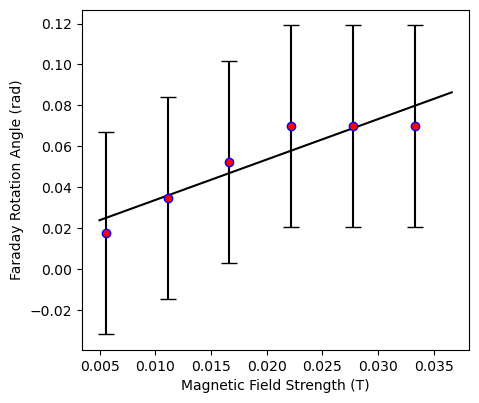

In [21]:
slope, intercept, err_slope, err_intercept, fig = PHYS231.LinearFit(
    xData=B,
    yData=theta_delta_rad,
    yErrors=err_theta_delta_rad,
    xlabel="Magnetic Field Strength",
    ylabel="Faraday Rotation Angle",
    xUnits="T",
    yUnits="rad",
    fill=False,
)

In [22]:

V = slope / L # rad / (T * m)

err_V = V * np.sqrt((err_slope / slope) ** 2 + (err_L / L) ** 2)

print(f"Verdet Constant (V): {V:.4f} +/- {err_V:.4f} rad/(T*m)")

Verdet Constant (V): 24.7087 +/- 4.9053 rad/(T*m)
